AEOTOR0246
February 20, 2026

In [1]:
import pandas as pd

# Load dataset
file_path = "C:/Users/Student/Downloads/StudentsPerformance.xlsx"
df = pd.read_excel(file_path)

# Display first few rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
# Identify categorical columns
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [3]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_encoded.drop("math score", axis=1)
y = df_encoded["math score"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (800, 14)
Testing set size: (200, 14)


In [4]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 4.214763142474852
Mean Squared Error (MSE): 29.095169866715494
R-squared (R²): 0.8804332983749564


In [6]:
# Create dataframe of coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort by absolute impact
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()
coefficients_sorted = coefficients.sort_values(
    by="Absolute Coefficient", ascending=False
)

coefficients_sorted.head(10)

,Feature,Coefficient,Absolute Coefficient
2,gender_male,13.064884,13.064884
6,race/ethnicity_group E,4.892649,4.892649
12,lunch_standard,3.510075,3.510075
13,test preparation course_none,3.289642,3.289642
9,parental level of education_master's degree,-1.400489,1.400489
10,parental level of education_some college,0.998856,0.998856
8,parental level of education_high school,0.929312,0.929312
11,parental level of education_some high school,0.756470,0.756470
1,writing score,0.724148,0.724148
7,parental level of education_bachelor's degree,-0.716901,0.716901


Based on the feature importance results, variables such as reading score and lunch status are considered actionable because they can be influenced through targeted educational interventions. 
Reading scores can be improved through literacy programs, tutoring, curriculum adjustments, and after school support initiatives. Since reading ability often correlates with overall academic performance, improving reading scores may positively impact math performance indirectly through enhanced comprehension and problem-solving skills. 
lunch status, particularly the proportion of students receiving free or reduced lunch, reflects socioeconomic conditions. While this variable is not directly academic, schools can influence it through nutritional programs, meal assistance expansion, and resource allocation. Improved  nutrition and financial support may enhance cognitive  function and classroom engagement, potentially improving math outcomes. 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the feature matrix used to train the model
X_full = X.copy()  
y_full = y.copy()

# Identify subset 
median_math = y_full.median()
subset_mask = y_full < median_math

X_subset_original = X_full[subset_mask].copy()
y_subset = y_full[subset_mask]

# Baseline predictions
baseline_predictions = model.predict(X_subset_original)

# Simulate Intervention

X_subset_modified = X_subset_original.copy()

# Increase reading score by 5%
X_subset_modified["reading score"] *= 1.05

# Decrease free/reduced lunch by 5%
# Since model has lunch_standard dummy, reducing free/reduced means increasing standard slightly
if "lunch_standard" in X_subset_modified.columns:
    X_subset_modified["lunch_standard"] *= 1.05

# Predict after intervention
intervention_predictions = model.predict(X_subset_modified)

impact = intervention_predictions - baseline_predictions

print("Average Baseline Predicted Math Score:", np.mean(baseline_predictions))
print("Average Post-Intervention Predicted Math Score:", np.mean(intervention_predictions))
print("Average Improvement:", np.mean(impact))



Average Baseline Predicted Math Score: 55.217797281097894
Average Post-Intervention Predicted Math Score: 56.007457846949535
Average Improvement: 0.7896605658516455


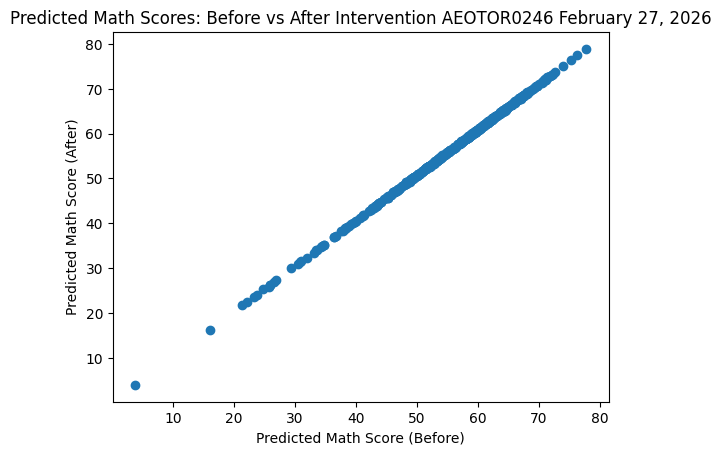

In [8]:
plt.figure()
plt.scatter(baseline_predictions, intervention_predictions)
plt.xlabel("Predicted Math Score (Before)")
plt.ylabel("Predicted Math Score (After)")
plt.title("Predicted Math Scores: Before vs After Intervention AEOTOR0246 February 27, 2026")
plt.show()

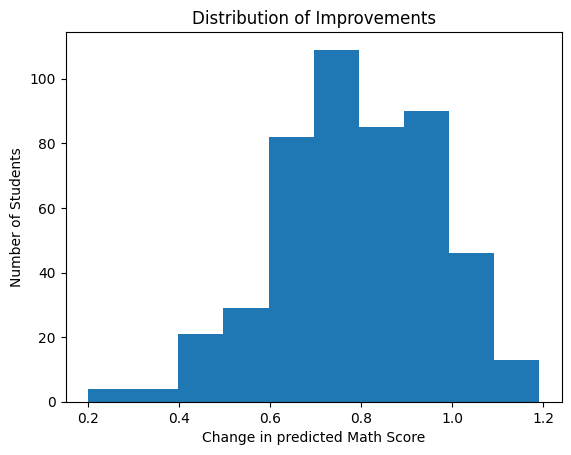

In [9]:
plt.figure()
plt.hist(impact)
plt.xlabel("Change in predicted Math Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Improvements")
plt.show()